PyTorch implementation of the **All Convolutional Net** discussed in _'Striving for Simplicity: The All Convolutional Net'_ (Springenberg et al., 2014)

In [ ]:
import time     # for recording training duration
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl

First, we implement a standard CNN with max-pooling layers to compare with its AllConv counterpart containing only convolutional layers. To understand the impact of data augmentation and batch normalisation on the results, we will create models with/without them for both cases.

We will evaluate the accuracy of these models on the CIFAR-10 dataset.

For reproducibility of results, we'll use a specific random seed, and also force determinism in cuDNN.

In [ ]:
seed = 26
torch.manual_seed(seed)
np.random.seed(seed)

if torch.cuda.is_available():
    # forces cuDNN to use deterministic algorithms only
    torch.backends.cudnn.deterministic = True
    # disables cuDNN autotuner that selects optimal algorithm based on hardware
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# hyperparameters
learningrate = 0.001
batchsize = 128
epochs = 10

In [6]:
datapath = '../data'

# loading CIFAR-10 dataset
train_cifar10 = datasets.CIFAR10(
    root=datapath,
    train=True,
    download=True,
    transform=transforms.ToTensor()     # here, transforms.toTensor() also normalises pixel values to [0, 1]
)
test_cifar10 = datasets.CIFAR10(
    root=datapath,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

# setting up dataloaders
trainloader_cifar10 = DataLoader(
    train_cifar10, 
    batch_size=batchsize, 
    shuffle=True                        # allows samples to be distributed among classes to reduce bias
)
testloader_cifar10 = DataLoader(
    test_cifar10, 
    batch_size=batchsize, 
    shuffle=False
)

In [ ]:
# retrieving class names
with open(datapath + "/cifar-10-batches-py/batches.meta", "rb") as f:
    metadata = pkl.load(f, encoding="ASCII")
    classes = metadata["label_names"]

print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


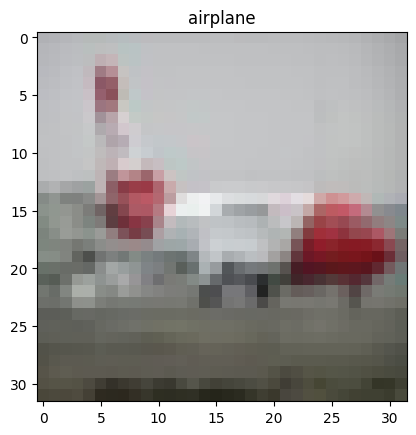

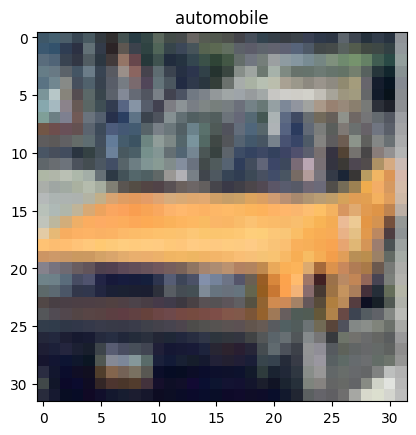

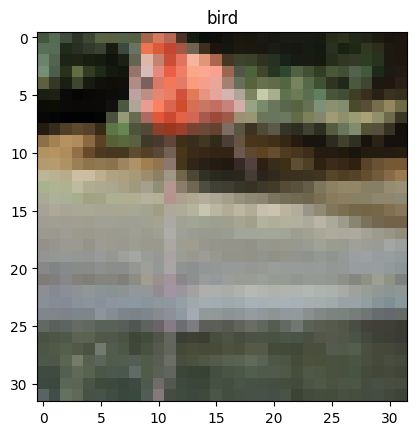

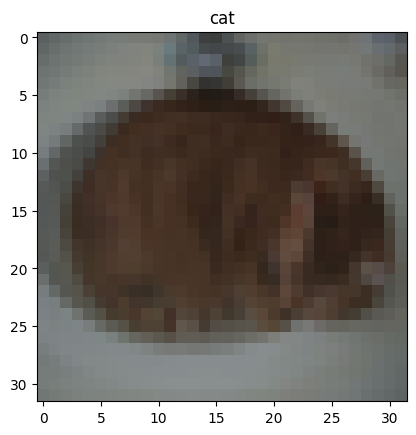

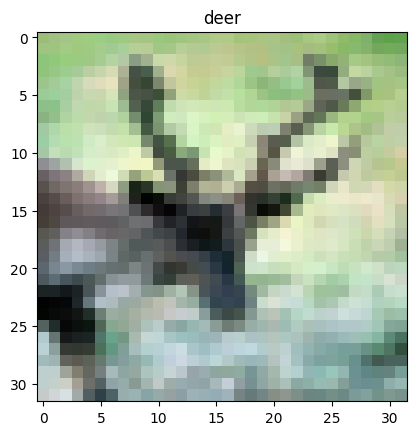

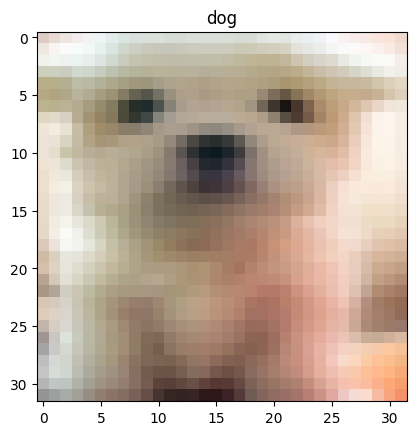

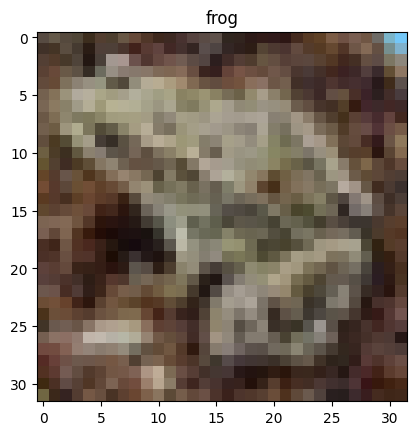

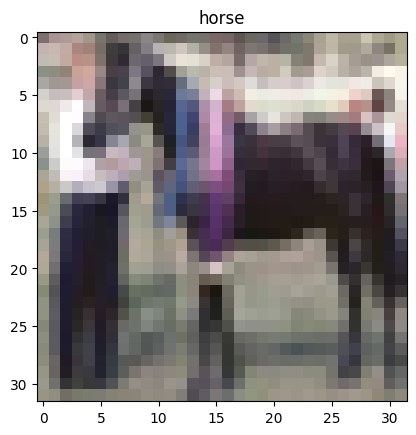

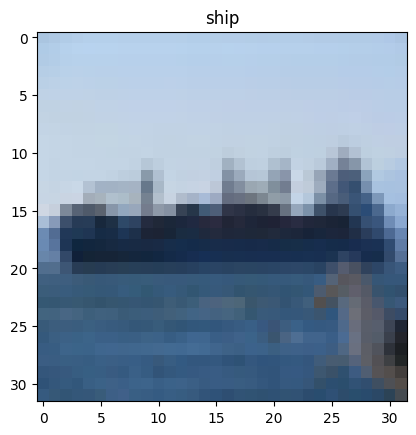

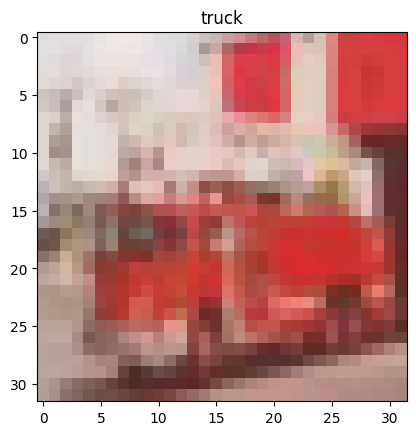

In [15]:
# retrieve a batch from training data (cifar10 is divided into five batches of 10k)
images, labels = next(iter(trainloader_cifar10))
# display an example image from each class
for i in range(10):
    index = np.argmax(labels.numpy() == i)
    plt.imshow(images[index].permute(1, 2, 0))     # permute to (H, W, C) for plotting
    plt.title(classes[labels[index]])
    plt.show()


In [19]:
class AllConv(nn.Module):
    pass